<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>investment strategy based on sentiment index(Jun Wang)</B></font></td></tr></table>

# content
* replication of the paper: [Quantifying Trading Behavior in Financial Markets Using Google Trends](http://www.nature.com/srep/2013/130425/srep01684/pdf/srep01684.pdf)
* develop investment strategy based on sentiment index
* discussions on the sentiment index strategy

# Google trend investment strategy

[Google trend investment strategy](http://localhost:8888/notebooks/%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90%EF%BC%88python%202020%20%E6%98%A5%E5%AD%A3%20haichao%EF%BC%89/jupyter%20coding/week%2015%20-%20investment%20strategy%20based%20on%20sentiment%20index/week%2015%20-%20Google%20trend%20investment%20strategy.ipynb)

# 3 build investment strategy based on sentiment index

基于随机森林模型，预测光线传媒股价涨跌，构建投资策略。我们可以学习如何生成交易信号、计算累计收益率。

## 3.1 prepare data and train the model

In [1]:
#  选择X的列和y的列
columns_sentiment = ["sentiment","positive","negative","ln_sentiment","comments_count","disaggreement","positive_shift_1","positive_shift_2",
"positive_shift_3","positive_shift_4","positive_shift_5","positive_shift_6","negative_shift_1","negative_shift_2","negative_shift_3",
"negative_shift_4","negative_shift_5","negative_shift_6","commulative_positive_lagged_1","commulative_positive_lagged_2","commulative_positive_lagged_3",
"commulative_positive_lagged_4","commulative_positive_lagged_5","commulative_positive_lagged_6","commulative_negative_lagged_1",
"commulative_negative_lagged_2","commulative_negative_lagged_3","commulative_negative_lagged_4","commulative_negative_lagged_5",
"commulative_negative_lagged_6","commulative_sentiment_score_lagged_1","commulative_sentiment_score_lagged_2",
"commulative_sentiment_score_lagged_3","commulative_sentiment_score_lagged_4","commulative_sentiment_score_lagged_5",
"commulative_sentiment_score_lagged_6","ln_commulative_sentiment_lagged_1","ln_commulative_sentiment_lagged_2",
"ln_commulative_sentiment_lagged_3","ln_commulative_sentiment_lagged_4","ln_commulative_sentiment_lagged_5",
"ln_commulative_sentiment_lagged_6","commulative_disaggreement_lagged_1","commulative_disaggreement_lagged_2",
"commulative_disaggreement_lagged_3","commulative_disaggreement_lagged_4","commulative_disaggreement_lagged_5","commulative_disaggreement_lagged_6","delta_sentiment",
"delta_positive","delta_negative","delta_ln_sentiment","delta_comments_count","delta_disaggreement","delta_commulative_positive_lagged_1",
"delta_commulative_positive_lagged_2","delta_commulative_positive_lagged_3","delta_commulative_positive_lagged_4","delta_commulative_positive_lagged_5",
"delta_commulative_positive_lagged_6","delta_commulative_negative_lagged_1","delta_commulative_negative_lagged_2",
"delta_commulative_negative_lagged_3","delta_commulative_negative_lagged_4","delta_commulative_negative_lagged_5",
"delta_commulative_negative_lagged_6","delta_commulative_sentiment_score_lagged_1","delta_commulative_sentiment_score_lagged_2",
"delta_commulative_sentiment_score_lagged_3","delta_commulative_sentiment_score_lagged_4","delta_commulative_sentiment_score_lagged_5",
"delta_commulative_sentiment_score_lagged_6","delta_ln_commulative_sentiment_lagged_1","delta_ln_commulative_sentiment_lagged_2",
"delta_ln_commulative_sentiment_lagged_3","delta_ln_commulative_sentiment_lagged_4","delta_ln_commulative_sentiment_lagged_5",
"delta_ln_commulative_sentiment_lagged_6","delta_commulative_disaggreement_lagged_1","delta_commulative_disaggreement_lagged_2",
"delta_commulative_disaggreement_lagged_3","delta_commulative_disaggreement_lagged_4","delta_commulative_disaggreement_lagged_5",
"delta_commulative_disaggreement_lagged_6"]
columns_market = ["volatility_lag1_GX","return_lag1_GX","close_lag1_GX","volatility_lag1_SH","return_lag1_SH","close_lag1_SH"]
columns_baidu = ['baidu_index', 'baidu_index_lag1', 'pct_change_baidu_index_lag1',
       'commulative_baidu_lagged_1', 'commulative_baidu_lagged_2',
       'commulative_baidu_lagged_3', 'commulative_baidu_lagged_4',
       'commulative_baidu_lagged_5', 'commulative_baidu_lagged_6',
       'baidu_delta_commulative_baidu_lagged_1',
       'baidu_delta_commulative_baidu_lagged_2',
       'baidu_delta_commulative_baidu_lagged_3',
       'baidu_delta_commulative_baidu_lagged_4',
       'baidu_delta_commulative_baidu_lagged_5',
       'baidu_delta_commulative_baidu_lagged_6'] ### 也可以使用光线传媒关键词，仿照谷歌指数的文章

Y_colum = ['up_down-1']  # 这里我们预测下一天的股价涨跌

In [2]:
#  选择X的列和y的列,这里我们对之前的函数做了少量修改：同时返回了收盘价

import pandas as pd
def load_data_set(X_columns,Y_colum):
    sentiment_trade_baidu = pd.read_csv("preprocessed_300251_comments_sentiment_trade_baidu.csv",
                                    index_col ="Date",
                                    parse_dates =["Date"])
    st = sentiment_trade_baidu.copy()
    st.dropna(axis = 0,inplace = True)
    X = st[X_columns].copy()
    y = st[Y_colum].copy()
    y = y[Y_colum]
    return X,y,sentiment_trade_baidu["Close_GX"]

In [3]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=200, max_depth=5,random_state=0)

X_columns = columns_baidu + columns_market + columns_sentiment
X,y,close_price = load_data_set(X_columns,Y_colum)

# 输入数据X[:1500], y[:1500]

clf.fit(X[:1500], y[:1500].values.ravel())

#使用测试数据做预测

y_pred = clf.predict(X[1500:])

## 3.2 what are the important features in our random forest?
在随机森林中某个特征X的重要性的计算方法如下：
* 1: 对于随机森林中的每一颗决策树,使用相应的OOB(袋外数据)数据来计算它的袋外数据误差,记为errOOB1.**（因为有放回的抽样，部分数据没有抽到）**
* 2: 随机地对袋外数据OOB所有样本的**特征X加入噪声干扰**(就可以随机的改变样本在特征X处的值),再次计算它的袋外数据误差,记为errOOB2.
* 3: 假设随机森林中有Ntree棵树,那么**对于特征X的重要性**=∑(errOOB2-errOOB1)/Ntree.

之所以可以用这个表达式来作为相应特征的重要性的度量值是因为：若给某个特征随机加入噪声之后,袋外的准确率大幅度降低,则说明这个特征对于样本的分类结果影响很大,也就是说它的重要程度比较高。

In [4]:
clf.feature_importances_ ### 随机森林拟合之后会生成特征重要性结果

array([0.01043167, 0.00773911, 0.0084127 , 0.00937388, 0.00750245,
       0.01000825, 0.00868175, 0.00908595, 0.00935874, 0.01109941,
       0.00758933, 0.00956806, 0.00882085, 0.00970193, 0.0054796 ,
       0.10007653, 0.02650799, 0.04190108, 0.00599316, 0.00703412,
       0.01119723, 0.00734615, 0.00286546, 0.00744993, 0.00717698,
       0.0057654 , 0.00891907, 0.0056718 , 0.00342959, 0.00332925,
       0.00586461, 0.00380707, 0.00500878, 0.00746249, 0.00534025,
       0.0039203 , 0.00933346, 0.00892084, 0.00752682, 0.00428347,
       0.00416556, 0.0060904 , 0.00636161, 0.00416791, 0.00539398,
       0.0067951 , 0.00607745, 0.00505433, 0.01028921, 0.01210639,
       0.00727378, 0.00939592, 0.00866383, 0.01499459, 0.01993625,
       0.01059804, 0.01735816, 0.00796326, 0.00910278, 0.01132525,
       0.01706068, 0.01772183, 0.01917501, 0.00724187, 0.00380357,
       0.00654544, 0.00801357, 0.00978064, 0.00572672, 0.00693786,
       0.00539253, 0.00916978, 0.00724264, 0.00785893, 0.00909

In [5]:
import numpy as np
importances = clf.feature_importances_
indices = np.argsort(importances)[-10:] 

### argsort 从低到高排序，并且找到对应的index

indices = indices[::-1]
features = np.array(X_columns)
for i in indices:
    print("{}:{}".format(features[i],importances[i]))

volatility_lag1_GX:0.10007652589504279
close_lag1_GX:0.04190108404937018
return_lag1_GX:0.026507985931151553
commulative_sentiment_score_lagged_4:0.019936251177201183
ln_commulative_sentiment_lagged_6:0.019175006235581618
ln_commulative_sentiment_lagged_5:0.017721830825943342
commulative_sentiment_score_lagged_6:0.01735815696823743
ln_commulative_sentiment_lagged_4:0.017060681634894156
delta_commulative_disaggreement_lagged_3:0.015758298243257484
commulative_sentiment_score_lagged_3:0.014994592070384833


Text(0.5, 0, 'Relative Importance')

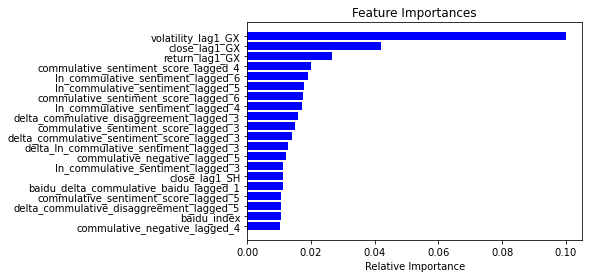

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

importances = clf.feature_importances_
indices = np.argsort(importances)[-20:]
features = np.array(X_columns)
plt.figure(1)
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), features[indices])
plt.xlabel('Relative Importance')

## Generate order signal

In [7]:
# 测试样本中，每天的下跌与上涨的概率预测值

probability = clf.predict_proba(X[1500:])

In [8]:
# 构造策略实验数据，包括预测的上涨与下跌概率值

data = pd.DataFrame(index=y[1500:].index,data={"close":close_price,
                                              "up_down":y_pred,
                                              "down_probability":probability[:,0],
                                              "up_probability":probability[:,1]})

In [9]:
data.head()

,close,up_down,down_probability,up_probability
Date,,,,
2017-10-12,9.95,0.0,0.541681,0.458319
2017-10-13,9.99,1.0,0.482392,0.517608
2017-10-16,9.49,1.0,0.449204,0.550796
2017-10-17,9.53,1.0,0.468627,0.531373
2017-10-18,9.37,0.0,0.508753,0.491247


* 如果down_probability>0.5,则当天以收盘价卖出，第二天以收盘价买入
* 如果up_probability>0.5,则当天以收盘价买入，第二天以收盘价卖出

此处交易信号比较灵活，大家可以调整这个概率阈值，修改买卖信号，如果调高，交易不频繁，如果调低，交易频繁

In [10]:
threshold = 0.5
data["short"] = (data.down_probability>threshold).astype("int")
data["long"] = (data.up_probability>threshold).astype("int")
data['order'] = data["long"] - data["short"] ### 做空 或 做多
data.head(3)

,close,up_down,down_probability,up_probability,short,long,order
Date,,,,,,,
2017-10-12,9.95,0.0,0.541681,0.458319,1,0,-1
2017-10-13,9.99,1.0,0.482392,0.517608,0,1,1
2017-10-16,9.49,1.0,0.449204,0.550796,0,1,1


## calculate return

In [11]:
# 第二天的return是前一天操作的真正受益，我们用return_shift表示
# 如果前一天是买，如果第二天return_shift为正，则盈利，否则亏损
# 如果前一天是卖，如果第二天return_shift为负，则盈利，否则亏损

data['return'] = data.close.pct_change()
data['return_shift'] = data['return'].shift(-1) ## 收益率要往上推1天
data.head()

,close,up_down,down_probability,up_probability,short,long,order,return,return_shift
Date,,,,,,,,,
2017-10-12,9.95,0.0,0.541681,0.458319,1,0,-1,NaN,0.004020
2017-10-13,9.99,1.0,0.482392,0.517608,0,1,1,0.004020,-0.050050
2017-10-16,9.49,1.0,0.449204,0.550796,0,1,1,-0.050050,0.004215
2017-10-17,9.53,1.0,0.468627,0.531373,0,1,1,0.004215,-0.016789
2017-10-18,9.37,0.0,0.508753,0.491247,1,0,-1,-0.016789,0.038420


In [12]:
# Compute returns of our strategy
data['ret_sentiment'] = data.order * data.return_shift ### 同时可以做空 或者 做多
data.head()

,close,up_down,down_probability,up_probability,short,long,order,return,return_shift,ret_sentiment
Date,,,,,,,,,,
2017-10-12,9.95,0.0,0.541681,0.458319,1,0,-1,NaN,0.004020,-0.004020
2017-10-13,9.99,1.0,0.482392,0.517608,0,1,1,0.004020,-0.050050,-0.050050
2017-10-16,9.49,1.0,0.449204,0.550796,0,1,1,-0.050050,0.004215,0.004215
2017-10-17,9.53,1.0,0.468627,0.531373,0,1,1,0.004215,-0.016789,-0.016789
2017-10-18,9.37,0.0,0.508753,0.491247,1,0,-1,-0.016789,0.038420,-0.038420


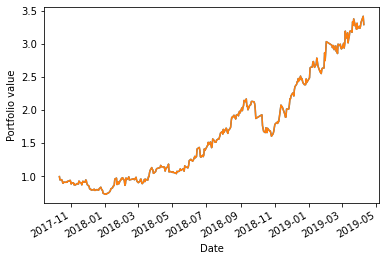

In [13]:
import matplotlib.pyplot as plt
(1 + data.ret_sentiment).cumprod().plot() # 这里没有考虑交易费
plt.ylabel('Portfolio value')
(1+data.ret_sentiment).cumprod().plot()
plt.show()

**Thanks a lot for your attention!!**

# Discussions on our investment strategy

## 思考：<font color=red face=雅黑>如果不可以做空，请大家运行或调整一下策略（例如调整threshold），并引入交易费（假设交易费是0.1%），看看如何获得较好的收益？</font>

<AxesSubplot:xlabel='Date'>

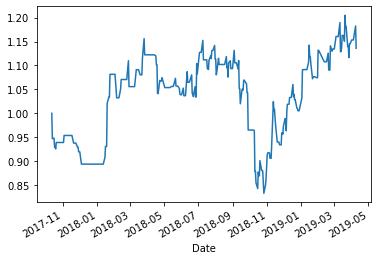

In [27]:
data['ret_sentiment_long'] = data.long * data.return_shift 
# 我国不允许做空，我们只做多，然后第二天卖出 ，可以把 order 改成 long

(1 + data.ret_sentiment_long - abs(data.long)*0.001).cumprod().plot() 
# 这里假设交易费是0.1%

## 思考：<font color=red face=雅黑>如果计算buy and hold策略的收益情况呢？（买进并持有）</font>

In [15]:
data['order_buy_hold'] = 0  
data.loc['2017-10-12',['order_buy_hold']] = 1
data.head()

,close,up_down,down_probability,up_probability,short,long,order,return,return_shift,ret_sentiment,ret_sentiment_long,order_buy_hold
Date,,,,,,,,,,,,
2017-10-12,9.95,0.0,0.541681,0.458319,1,0,-1,NaN,0.004020,-0.004020,0.000000,1
2017-10-13,9.99,1.0,0.482392,0.517608,0,1,1,0.004020,-0.050050,-0.050050,-0.050050,0
2017-10-16,9.49,1.0,0.449204,0.550796,0,1,1,-0.050050,0.004215,0.004215,0.004215,0
2017-10-17,9.53,1.0,0.468627,0.531373,0,1,1,0.004215,-0.016789,-0.016789,-0.016789,0
2017-10-18,9.37,0.0,0.508753,0.491247,1,0,-1,-0.016789,0.038420,-0.038420,0.000000,0


<AxesSubplot:xlabel='Date'>

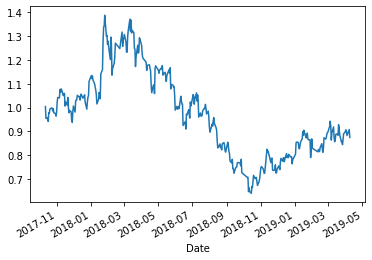

In [16]:
data['ret_buy_hold'] = data.return_shift
(1 + data.ret_buy_hold).cumprod().plot() ### 累计收益率的效果

## 思考：<font color=red face=雅黑>如果每天随机投资（只允许做多的情况），看看如何获得的收益情况如何？平均收益率是多少?</font>

伯努利分布指的是对于随机变量X有, 参数为p(0<p<1)，如果它分别以概率p和1-p取1和0为值。EX= p,DX=p(1-p)。

In [17]:
import numpy as np
n=1
p = 0.5
size = len(data)
order_random = np.random.binomial(n,p,size) # （伯努利分布）返回的是 n 次试验中事件发生的次数,重复做size次。

In [18]:
order_random

array([1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,

<AxesSubplot:xlabel='Date'>

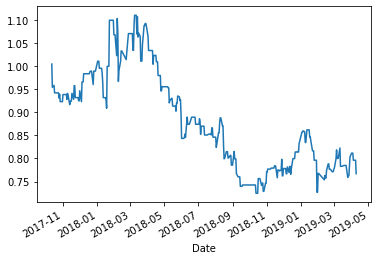

In [19]:
data['order_random'] = order_random
data['ret_random'] = data.order_random * data.return_shift
(1 + data.ret_random).cumprod().plot()

## 思考：<font color=red face=雅黑>如何评估基于情感指数的投资策收益是否比随机投资好？</font>

如果做5000次随机投资仿真（只允许做多的情况），看看平均收益率的分布如何？

In [20]:
import numpy as np
trials = 10000
n=1
p = 0.5
size = len(data)
mean_return_list = []

def random_once():
    data['order_random'] = np.random.binomial(n,p,size)
    data['ret_random'] = data.order_random * data.return_shift
    return data.ret_random.mean() ### 每一次得到投资受益的均值

for i in range(trials):
    mean_return = random_once()
    mean_return_list.append(mean_return)

(array([  3.,   8.,  31.,  37.,  80., 115., 194., 293., 398., 546., 693.,
        802., 915., 913., 887., 881., 795., 674., 517., 476., 289., 201.,
        117.,  62.,  34.,  21.,  12.,   4.,   0.,   2.]),
 array([-2.53420481e-03, -2.34981831e-03, -2.16543181e-03, -1.98104531e-03,
        -1.79665881e-03, -1.61227231e-03, -1.42788581e-03, -1.24349931e-03,
        -1.05911281e-03, -8.74726312e-04, -6.90339812e-04, -5.05953312e-04,
        -3.21566812e-04, -1.37180312e-04,  4.72061883e-05,  2.31592688e-04,
         4.15979188e-04,  6.00365688e-04,  7.84752188e-04,  9.69138688e-04,
         1.15352519e-03,  1.33791169e-03,  1.52229819e-03,  1.70668469e-03,
         1.89107119e-03,  2.07545769e-03,  2.25984419e-03,  2.44423069e-03,
         2.62861719e-03,  2.81300369e-03,  2.99739019e-03]),
 <BarContainer object of 30 artists>)

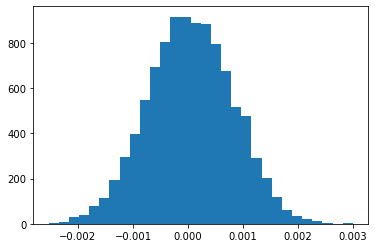

In [21]:
plt.hist(mean_return_list,bins =30)

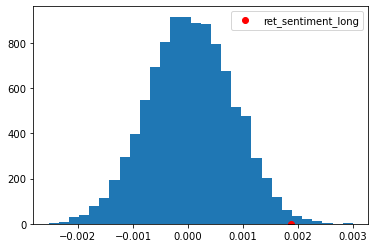

In [22]:
plt.hist(mean_return_list,bins = 30)
return_sentiment_long = data['ret_sentiment_long'].mean()
plt.plot(return_sentiment_long,0,'ro',label = "ret_sentiment_long")
plt.legend(loc='upper right')
plt.show()

In [23]:
std = np.array(mean_return_list).std()
(return_sentiment_long - np.array(mean_return_list).mean())/std ### 标准差

2.381177740620619

## 思考：<font color=red face=雅黑>为了比较我们的long和随机投资的操作差异，比较long的操作和order_random的差异是否显著</font>

In [24]:
import numpy as np
trials = 10000
n=1
p = 0.5
size = len(data)
ratios = []

def random_once():
    order_random = np.random.binomial(n,p,size)
    return order_random.mean()

for i in range(trials):
    r = random_once()
    ratios.append(r)

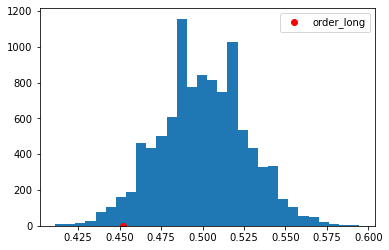

In [25]:
plt.hist(ratios,bins = 30)
ratio_long = data.long.mean()
plt.plot(ratio_long,0,'ro',label = "order_long") ## ratio_long 做多的唯一的比率
plt.legend(loc='upper right')

In [26]:
p_value = sum(np.array(ratios)<=ratio_long)/len(mean_return_list)
p_value 

### 显著性水平

0.0403

最后提示：简单起见，这里的较好收益仅仅指均值。投资是由风险的，如果大家感兴趣，可以考虑使用夏普比率来评估您的投资策略。

# reading material after class
Siering, M., Koch, J., & Deokar, A. V. (2016). Detecting Fraudulent Behavior on Crowdfunding Platforms: The Role of Linguistic and Content-Based Cues in Static and Dynamic Contexts. Journal of Management Information Systems, 33(2), 421-455.

**Thanks a lot for your attention!**